2️⃣ Login to Hugging Face inside Colab

In Colab, before training, run:

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


🧠 What this pipeline guarantees

This pipeline follows competition-grade ML:


---


RAW TRAIN DATA
   ↓
StratifiedKFold (no leakage)
   ↓
For each fold:
   Train on 4/5
   Validate on 1/5
   Save model → HF branch
   Log metrics
   ↓
ENSEMBLE all folds
   ↓
Predict blind test
   ↓
submission.csv


📦 1️⃣ Install (Colab)

In [ ]:
!pip install -q transformers datasets accelerate emoji arabert scikit-learn wandb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 13.9 MB/s eta 0:00:00


In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.8 MB/s eta 0:00:00


📚 2️⃣ Load dataset (NO split yet)

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "csv",
    data_files="hf://datasets/aomar85/Subtask_B_train/Subtask_B_train.csv",
    split="train"
)

print(len(dataset))



1024


In [ ]:
dataset

Dataset({
    features: ['id', 'sentence', 'topic', 'label'],
    num_rows: 1024
})

In [ ]:
import pandas as pd
from collections import Counter
total = len(dataset)
label_counts = Counter(dataset["label"])
print(label_counts)

df = pd.DataFrame.from_dict(label_counts, orient="index", columns=["Count"])
df["Percentage (%)"] = (df["Count"] / total) * 100
df = df.sort_index()

print(f"Total samples: {total}")
print(df)

Counter({'against': 361, 'pro': 348, 'neutral': 315})
Total samples: 1024
         Count  Percentage (%)
against    361       35.253906
neutral    315       30.761719
pro        348       33.984375


In [ ]:
import pandas as pd

In [ ]:
df = dataset.to_pandas()
total = len(df)

In [ ]:
topic_counts = df["topic"].value_counts().sort_index()

topic_df = pd.DataFrame({
    "Count": topic_counts,
    "Percentage (%)": (topic_counts / total) * 100
})

print("Total samples:", total)
print("\nTopic Distribution:")
print(topic_df)

Total samples: 1024

Topic Distribution:
                                                    Count  Percentage (%)
topic                                                                    
التطبيع مع اسرائيل                                    491       47.949219
وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ...    533       52.050781


In [ ]:
label_topic_counts = pd.crosstab(df["topic"], df["label"])
print("\nLabel Counts Per Topic:")
print(label_topic_counts)


Label Counts Per Topic:
label                                               against  neutral  pro
topic                                                                    
التطبيع مع اسرائيل                                      168      177  146
وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ...      193      138  202


In [ ]:
label_topic_percent = pd.crosstab(
    df["topic"],
    df["label"],
    normalize="index"
) * 100

print("\nLabel Percentage Per Topic:")
print(label_topic_percent)


Label Percentage Per Topic:
label                                                 against    neutral  \
topic                                                                      
التطبيع مع اسرائيل                                  34.215886  36.048880   
وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ...  36.210131  25.891182   

label                                                     pro  
topic                                                          
التطبيع مع اسرائيل                                  29.735234  
وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ...  37.898687  


In [ ]:
summary = pd.crosstab(df["topic"], df["label"], margins=True)
summary

label,against,neutral,pro,All
topic,,,,
التطبيع مع اسرائيل,168,177,146,491
وجود اللاجئين والمهاجرين في الأردن (من فلسطين ، سوريا ، العراق),193,138,202,533
All,361,315,348,1024


In [ ]:
test = load_dataset(
    "csv",
    data_files="hf://datasets/aomar85/Subtask_B_train/Subtask_B_test_noLabel.csv"
)["train"]

print("Train with Val size:", len(dataset))

print("Test size:", len(test))



Subtask_B_test_noLabel.csv:   0%|          | 0.00/51.8k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Train with Val size: 1024
Test size: 181


🧹 3️⃣ Clean + tokenize

In [ ]:
checkpoint = "aubmindlab/bert-base-arabertv02-twitter"

In [ ]:
import re, emoji
from transformers import AutoTokenizer
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def clean(example):
    s = emoji.demojize(str(example["sentence"])) # Changed to lowercase "sentence"
    t = emoji.demojize(str(example["topic"]))    # Changed to lowercase "topic"
    s = re.sub(r"[^؀-ۿ\w\s:]", " ", s)
    return {"sentence": s, "topic": t} # Return with lowercase keys to maintain consistency
def clean_val(example):
    s = emoji.demojize(str(example["sentence"]))
    t = emoji.demojize(str(example["topic"]))
    s = re.sub(r"[^؀-ۿ\w\s:]", " ", s)
    return {"sentence": s, "topic": t}

#%% ============== TEXT PREPROCESSING ==============
def normalize_arabic(text):
    """Basic Arabic text normalization"""
    if pd.isna(text) or not isinstance(text, str):
        return ""

    # Remove diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)

    # Normalize alef variants
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize alef maqsura to yaa
    text = re.sub(r'ى', 'ي', text)

    # Normalize taa marbuta to haa
    text = re.sub(r'ة', 'ه', text)

    # Remove tatweel
    text = re.sub(r'ـ', '', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove URLs and mentions
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    return text.strip()
def remove_missing(example):
    return example["sentence"] is not None and example["label"] is not None and example["sentence"].strip() != ""

def deduplicate(ds):
    seen = set()
    def is_unique(example):
        if example["sentence"] in seen: # Changed to lowercase "sentence"
            return False
        seen.add(example["sentence"]) # Changed to lowercase "sentence"
        return True
    return ds.filter(is_unique)


In [ ]:

dataset = dataset.map(clean)
#dataset = dataset.filter(remove_missing) #newly added
dataset = dataset.map(lambda x: {"sentence": normalize_arabic(x["sentence"])}) # Changed to lowercase "sentence"
dataset = dataset.map(lambda x: {"topic": normalize_arabic(x["topic"])})     # Changed to lowercase "topic"
dataset= deduplicate(dataset)  # newly added

label2id = {"pro": 0, "against": 1, "neutral": 2}
id2label = {0: "pro", 1: "against", 1: "neutral"} # Fixed duplicated key '1'
id2label = {0: "pro", 1: "against", 2: "neutral"}
def encode(example):
    example["labels"] = label2id[example["label"]]
    return example

dataset = dataset.map(encode)


In [ ]:
## Other Solution is Concatinating Sentence with Tpoic with prompt
def build_input(example):
    example["text"] = (
        f"الهدف: {example['topic']} "
        f"[SEP] الموقف من: {example['sentence']}"
    )
    return example
dataset = dataset.map(build_input)

In [ ]:
dataset['text'][1]

'الهدف: التطبيع مع اسرائيل [SEP] الموقف من: التطبيع مع اسرائيل سيكون خير ان شاء الله'

In [ ]:
dataset['label'][1]

'pro'

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"],
                     truncation=True)

In [ ]:
dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

In [ ]:
# Suppose dataset['input_ids'][941] is a single sequence of token IDs
token_ids = dataset['input_ids'][1]

# Convert back to tokens (list of token strings)
tokens = tokenizer.convert_ids_to_tokens(token_ids)

# If you want the full decoded string
text = tokenizer.decode(token_ids, skip_special_tokens=True)

print(tokens)  # List of tokens
#print(text)    # Full decoded sentence

['[CLS]', 'الهدف', ':', 'التطبيع', 'مع', 'اسرائيل', '[SEP]', 'الموقف', 'من', ':', 'التطبيع', 'مع', 'اسرائيل', 'سيكون', 'خير', 'ان', 'شاء', 'الله', '[SEP]']


In [ ]:
print(tokens)  # List of tokens

['[CLS]', 'الهدف', ':', 'التطبيع', 'مع', 'اسرائيل', '[SEP]', 'الموقف', 'من', ':', 'التطبيع', 'مع', 'اسرائيل', 'سيكون', 'خير', 'ان', 'شاء', 'الله', '[SEP]']


In [ ]:
dataset = dataset.map(tokenize, batched=True)
dataset = dataset.remove_columns([col for col in dataset.column_names if col not in ["input_ids", "attention_mask", "token_type_ids", "labels"]]) # Keep relevant tokenized columns and 'labels'
dataset.set_format("torch")

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest"  # dynamic padding per batch
)

In [ ]:
dataset

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1023
})

4️⃣ Weighted loss

In [ ]:
import torch
import numpy as np
import pandas as pd
import zipfile
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Configuration
# -----------------------------
repo_id = "aomar85/Twitter_large1024"



num_labels = 3
ID2LABEL = {0: "pro", 1: "against", 2: "neutral"}

# -----------------------------
# Metrics function
# -----------------------------
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = f1_score(labels, predictions, average='macro')
    weighted_f1 = f1_score(labels, predictions, average='weighted')
    accuracy = accuracy_score(labels, predictions)
    per_class_f1 = f1_score(labels, predictions, average=None)
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'f1_pro': per_class_f1[0],
        'f1_against': per_class_f1[1],
        'f1_neutral': per_class_f1[2],
    }


# -----------------------------
# K-Fold setup
# -----------------------------
labels = np.array(dataset["labels"])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_f1 = 0
best_trainer = None
best_fold_metrics = None
best_val_ds = None

print("Step\tTrain Loss\tVal Loss\tAccuracy\tMacro-F1\tWeighted-F1")
print("-"*80)

# -----------------------------
# Weighted Trainer definition
# -----------------------------
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


Step	Train Loss	Val Loss	Accuracy	Macro-F1	Weighted-F1
--------------------------------------------------------------------------------


In [ ]:
from collections import Counter
import pandas as pd
import torch

# -------------------------------
# K-Fold loop
# -------------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), 1):

    train_ds = dataset.select(train_idx)
    val_ds = dataset.select(val_idx)

    # -------------------------------
    # 🔹 Safe label counts & percentages (tensor fix)
    # -------------------------------
    train_labels = [int(l.item()) if isinstance(l, torch.Tensor) else int(l) for l in train_ds["labels"]]
    val_labels   = [int(l.item()) if isinstance(l, torch.Tensor) else int(l) for l in val_ds["labels"]]

    train_counts = Counter(train_labels)
    val_counts   = Counter(val_labels)
    '''
    # All unique labels
    all_labels = sorted(set(train_counts.keys()).union(val_counts.keys()))

    # Prepare lists for DataFrame
    labels_list = []
    train_count_list = []
    train_pct_list = []
    val_count_list = []
    val_pct_list = []

    for label in all_labels:
        labels_list.append(label)
        train_count = train_counts.get(label, 0)
        val_count   = val_counts.get(label, 0)
        train_count_list.append(train_count)
        val_count_list.append(val_count)
        train_pct_list.append((train_count / len(train_ds)) * 100)
        val_pct_list.append((val_count / len(val_ds)) * 100)

    split_df = pd.DataFrame({
        "Label": labels_list,
        "Train Count": train_count_list,
        "Train %": train_pct_list,
        "Validation Count": val_count_list,
        "Validation %": val_pct_list
    })

    print(f"\n===== Fold {fold} Label Distribution =====")
    print(f"Train size: {len(train_ds)}, Validation size: {len(val_ds)}")
    print(split_df)
    '''
    # -------------------------------
    # Original code continues here
    # -------------------------------
    y = np.array(train_labels)
    w = compute_class_weight(class_weight="balanced", classes=np.arange(num_labels), y=y)
    class_weights = torch.tensor(w, dtype=torch.float)

    config = AutoConfig.from_pretrained(checkpoint)
    config.hidden_dropout_prob = 0.2
    config.num_labels = num_labels

    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, config=config)

    args = TrainingArguments(
       # output_dir=f"./fold_{fold}",
        eval_strategy="steps",
        eval_steps=50,
        save_strategy="steps",
        save_steps=50,
        hub_model_id = f"{repo_id}-fold{fold}",   # 👈 dynamic repo name
        push_to_hub=True,
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1",
        greater_is_better=True,
        num_train_epochs=10,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        learning_rate=2e-5, #3e-5

        gradient_accumulation_steps=4,
        gradient_checkpointing=True,
        weight_decay=0.01,
        fp16=False, # Changed to False
        logging_strategy="steps",
        logging_steps=50,
        report_to="none",
        optim='adamw_torch' # Explicitly use PyTorch's AdamW to avoid fused optimizer issues on XLA

    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        #tokenizer=tokenizer, # Removed this line
        class_weights=class_weights,
        compute_metrics=compute_metrics,
        data_collator=data_collator , # 👈 this enables dynamic padding
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    # Train
    trainer.train()

    # Evaluate
    metrics = trainer.evaluate()
    print(
        f"{fold}\t"
        f"{metrics.get('train_loss', 0):.4f}\t"
        f"{metrics['eval_loss']:.4f}\t"
        f"{metrics['eval_accuracy']:.4f}\t"
        f"{metrics['eval_macro_f1']:.4f}\t"
        f"{metrics['eval_weighted_f1']:.4f}"
    )

    # Track best fold
    if metrics["eval_macro_f1"] > best_f1:
        best_f1 = metrics["eval_macro_f1"]
        best_trainer = trainer
        best_fold_metrics = metrics
        best_val_ds = val_ds  # Keep validation dataset for submission

    del model
    torch.cuda.empty_cache()

# -----------------------------
# Best fold summary
# -----------------------------
print("\n🏆 Best Fold Metrics:")
print(
    f"Loss: {best_fold_metrics['eval_loss']:.4f} | "
    f"Acc: {best_fold_metrics['eval_accuracy']:.4f} | "
    f"Macro-F1: {best_fold_metrics['eval_macro_f1']:.4f} | "
    f"Weighted-F1: {best_fold_metrics['eval_weighted_f1']:.4f}"
)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

# Put model in eval mode
best_trainer.model.eval()

# Get predictions on best validation set
preds = best_trainer.predict(best_val_ds)
y_true = np.array(best_val_ds["labels"])
y_pred = np.argmax(preds.predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: Detailed classification report
report = classification_report(y_true, y_pred, target_names=["Against", "Neutral", "Pro"])
print("Classification Report:\n", report)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', xticklabels=["Against","Neutral","Pro"], yticklabels=["Against","Neutral","Pro"], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Fold")
plt.show()


In [ ]:
print(f"\n🏆 Best fold:  with F1 = {best_f1:.4f}")

best_trainer.push_to_hub(
    commit_message=f"Best fold:  (F1={best_f1:.4f})"
)

## Confusion MAtrix

In [ ]:
best_val_ds

Dataset({
    features: ['id', 'sentence', 'topic', 'prediction', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 180
})

In [ ]:
from datasets import load_dataset
val_ds = load_dataset(
    "csv",
    data_files="hf://datasets/aomar85/Subtask_B_train/Subtask_B_test_noLabel.csv",
    split="train")

Subtask_B_test_noLabel.csv:   0%|          | 0.00/51.8k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
val_ds = val_ds.map(clean_val)
val_ds = val_ds.map(lambda x: {"sentence": normalize_arabic(x["sentence"])})
val_ds = val_ds.map(lambda x: {"topic": normalize_arabic(x["topic"])})
val_ds = deduplicate(val_ds)

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Map:   0%|          | 0/181 [00:00<?, ? examples/s]

Filter:   0%|          | 0/181 [00:00<?, ? examples/s]

In [ ]:
# Works Only for Conctenation version
import torch
import pandas as pd
import zipfile
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "aomar85/Twitter_concatenatewithPrompttrainva1024-fold4"
PREDICTIONS_CSV = "prediction.csv"
PREDICTIONS_ZIP = "prediction.zip"

ID2LABEL = {0: "pro", 1: "against", 2: "neutral"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model + tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

# 🔥 BUILD INPUT EXACTLY LIKE TRAINING

def build_input(example):
    example["text"] = (
        f"الهدف: {example['topic']} "
        f"[SEP] الموقف من: {example['sentence']}"
    )
    return example

val_ds = val_ds.map(build_input)

# Tokenize EXACTLY like training
def tokenize_val(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128   # ⚠️ use same value as training
    )

val_ds = val_ds.map(tokenize_val, batched=True)

# Save ids
ids = list(val_ds["id"])

# Torch format
val_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask"]
)

# Inference
predictions = []

with torch.no_grad():
    for example in val_ds:
        inputs = {
            "input_ids": example["input_ids"].unsqueeze(0).to(device),
            "attention_mask": example["attention_mask"].unsqueeze(0).to(device),
        }

        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=-1).item()
        predictions.append(ID2LABEL[pred_id])

# Build submission
submission_df = pd.DataFrame({
    "id": ids,
    "prediction": predictions
})

submission_df.to_csv(PREDICTIONS_CSV, index=False, encoding="utf-8")

with zipfile.ZipFile(PREDICTIONS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(PREDICTIONS_CSV)

print("Saved:", PREDICTIONS_ZIP)



print(submission_df.head())
print("Rows:", len(submission_df))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Saved: prediction.zip
     id prediction
0  1025        pro
1  1026    neutral
2  1027    against
3  1028        pro
4  1029        pro
Rows: 180


In [ ]:
dataset

Dataset({
    features: ['id', 'sentence', 'topic', 'label', 'labels', 'text'],
    num_rows: 1023
})

In [ ]:
labels = np.array(dataset["labels"])

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

# 1. Setup
model_name = "aomar85/A2NLP-STANCENAKBA2026-CROSS-TOPIC"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

all_preds = []
all_labels = []
ID2LABEL = {0: "pro", 1: "against", 2: "neutral"}

# 2. Re-trace the 5-fold splits (Ensure random_state matches your training)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Assuming 'dataset' and 'labels' are defined as in your training script
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), 1):
    val_ds = dataset.select(val_idx)

    # Simple Trainer for inference only
    trainer = Trainer(
        model=model,
        data_collator=data_collator # Add data_collator for proper padding
    )

    # 3. Predict without training
    output = trainer.predict(val_ds)
    preds = np.argmax(output.predictions, axis=1)

    all_preds.extend(preds)
    all_labels.extend(output.label_ids)

# 4. Generate and Plot Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(ID2LABEL.values()))
disp.plot(cmap=plt.cm.Blues)
#plt.title(f"Aggregated OOF Confusion Matrix\n{model_name}")
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ValueError: You should supply an encoding or a list of encodings to this method that includes input_ids, but you provided ['labels']

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, default_data_collator

# ==================================
# 1️⃣ Setup
# ==================================
model_name = "aomar85/A2NLP-STANCENAKBA2026-CROSS-TOPIC"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Label mappings
label2id = {"pro": 0, "against": 1, "neutral": 2}
id2label = {0: "pro", 1: "against", 2: "neutral"}

# ==================================
# 2️⃣ Encode numeric labels & drop original
# ==================================
def encode_labels(example):
    example["labels"] = label2id[example["label"]]
    return example

dataset = dataset.map(encode_labels)
dataset = dataset.remove_columns("label")  # drop string label to avoid Trainer errors

# ==================================
# 3️⃣ Build the 'text' column
# ==================================
def build_input(example):
    example["text"] = f"الهدف: {example['topic']} [SEP] الموقف من: {example['sentence']}"
    return example

dataset = dataset.map(build_input)

# ==================================
# 4️⃣ Tokenize
# ==================================
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],  # numeric labels only
    output_all_columns=True
)

labels = np.array(tokenized_dataset["labels"])

# ==================================
# 5️⃣ 5-Fold OOF Predictions
# ==================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preds = np.zeros(len(labels), dtype=int)
error_records = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), 1):
    print(f"\n=== Fold {fold} ===")

    # Validation set
    val_ds = tokenized_dataset.select([int(i) for i in val_idx])

    # Load a fresh model per fold
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label2id))

    # Trainer for inference
    trainer = Trainer(
        model=model,
        data_collator=default_data_collator
    )

    # Predict
    output = trainer.predict(val_ds)
    preds = np.argmax(output.predictions, axis=1)

    # Store predictions & misclassified examples
    for i, idx in enumerate(val_idx):
        idx = int(idx)
        all_preds[idx] = int(preds[i])
        if preds[i] != labels[idx]:
            error_records.append({
                "sentence": tokenized_dataset[idx]["sentence"],
                "topic": tokenized_dataset[idx]["topic"],
                "ground_truth": int(labels[idx]),
                "prediction": int(preds[i])
            })

# ==================================
# 6️⃣ Aggregated Confusion Matrix
# ==================================
cm = confusion_matrix(labels, all_preds)
cm_df = pd.DataFrame(cm, index=[id2label[i] for i in range(len(id2label))],
                     columns=[id2label[i] for i in range(len(id2label))])
print("\nAggregated OOF Confusion Matrix:\n", cm_df)

# Optional: plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[id2label[i] for i in range(len(id2label))])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ==================================
# 7️⃣ Misclassified Examples DataFrame
# ==================================
df_errors = pd.DataFrame(error_records)
df_errors["ground_truth"] = df_errors["ground_truth"].map(id2label)
df_errors["prediction"] = df_errors["prediction"].map(id2label)

# ==================================
# 8️⃣ Show Top 3 Examples Per Confusion Pair
# ==================================
print("\n=== Error Examples Per Confusion Pair ===")
for gt in id2label.values():
    for pred in id2label.values():
        if gt != pred:
            subset = df_errors[
                (df_errors["ground_truth"] == gt) &
                (df_errors["prediction"] == pred)
            ]
            if not subset.empty:
                print(f"\n{gt} predicted as {pred}:")
                for _, row in subset[["sentence", "topic"]].head(3).iterrows():
                    print(f"  Sentence: {row['sentence']}, Topic: {row['topic']}")

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

KeyError: 'label'

In [ ]:
df_errors

,sentence,topic,ground_truth,prediction
0,أنا فعلاً مبسوطة من أعداد الدس لايك المتجاوزه ...,التطبيع مع اسرائيل,against,pro
1,التطبيع عمره مايجي من الشعوب العربيه الحكام يط...,التطبيع مع اسرائيل,neutral,against
2,مواطنين العرب و الله كلام يبعت على الضحك ..و...,التطبيع مع اسرائيل,neutral,against
3,اللاجئين السوريين في لبنان و سوريا و الاردن و ...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,pro,neutral
4,#اللأجئين_السوريين_في_المخيمات_الاردن \r\n كل...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,neutral,pro
...,...,...,...,...
79,فرحان بتطبيع متدري ان التطبيع ذا هو الي بيدمر ...,التطبيع مع اسرائيل,pro,against
80,افتتاح بازار لدعم اللاجئين السوريين في #الأردن...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,pro,neutral
81,ياذا التطبيع الي صدعوا رأسنا فيه من ولدت وعرفت...,التطبيع مع اسرائيل,neutral,against
82,تطيحون قروضنا نطبع غير هالحجي مافيه 😏,التطبيع مع اسرائيل,neutral,against


In [ ]:
["sentence", "topic", "ground_truth", "prediction"]

['sentence', 'topic', 'ground_truth', 'prediction']

In [ ]:
# Count all confusion pairs
confusion_counts = (
    df_errors
    .groupby(["ground_truth", "prediction"])
    .size()
    .reset_index(name="count")
)

print(confusion_counts)

  ground_truth prediction  count
0      against    neutral     17
1      against        pro     12
2      neutral    against     27
3      neutral        pro     12
4          pro    against      9
5          pro    neutral      7


Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]

Map:   0%|          | 0/1024 [00:00<?, ? examples/s]


=== Fold 1 ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...


=== Fold 4 ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Fold 5 ===


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Aggregated OOF Confusion Matrix:
          pro  against  neutral
pro      332        9        7
against   12      332       17
neutral   12       27      276


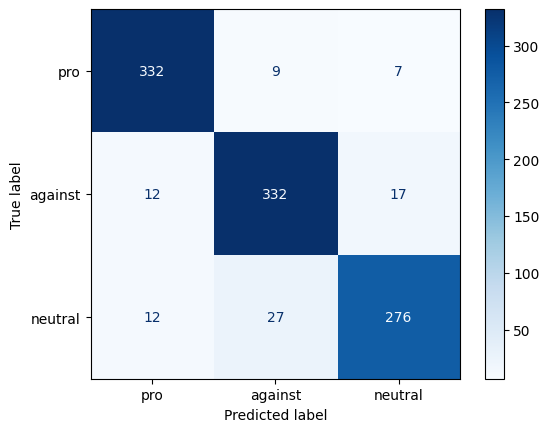


=== Error Examples Per Confusion Pair ===

pro predicted as against:
  Sentence: الدول العربية من مراكش للبحرين اذا ما تطبع من الكيان تبقى تعيش بعدم استقرار وتتحرك من الداخل الذيول والعملاء, Topic: التطبيع مع اسرائيل
  Sentence: ليس هناك هدف من استمرار الحرب، فقد تمكنت اسرائيل من احتلال فلسطين منذ زمن طويل، وكل هذا الوقت يستمر مع الحرب الشعب الفلسطيني في المعاناه. ارضوا بالأمر الواقع، فالعرب لا يملكون القوه لفعل اي شيء. شيء مضحك ولو انه بلاء، ولكن اتوقع السعوديه أن تفعل نفس الشيء من أجل بقاء بن سلمان في الحكم. هذا كله في الواقع، استسلام رسمي من الدول العربيه. توقعوا حقد الفلسطينيين لكافة العرب أن يزداد... وربما يتفجر ويتحول إلى عمليات ارهابيه في البلاد العربيه. ولا الومهم ابدا.. شيء طبيعي.., Topic: التطبيع مع اسرائيل
  Sentence: من الخطأ اعتبار التطبيع مع اسرائيل خيانة للقضية الفلسطينية, Topic: التطبيع مع اسرائيل

pro predicted as neutral:
  Sentence: اللاجئين السوريين في لبنان و سوريا و الاردن و تركيا مع دخول الشتاء يجب أن يكون له أهمية قصوى من خلال الجامعة العربية و منظمة المؤتمر ال

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, default_data_collator
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==================================
# 1️⃣ Load Dataset
# ==================================
dataset = load_dataset(
    "csv",
    data_files="hf://datasets/aomar85/Subtask_B_train/Subtask_B_train.csv",
    split="train"
)

# ==================================
# 2️⃣ Label Mapping
# ==================================
label2id = {"pro": 0, "against": 1, "neutral": 2}
id2label = {0: "pro", 1: "against", 2: "neutral"}

def encode_labels(example):
    example["labels"] = label2id[example["label"]]
    return example

dataset = dataset.map(encode_labels)
dataset = dataset.remove_columns("label")  # remove string labels

# ==================================
# 3️⃣ Build input text
# ==================================
def build_input(example):
    example["text"] = f"الهدف: {example['topic']} [SEP] الموقف من: {example['sentence']}"
    return example

dataset = dataset.map(build_input)

# ==================================
# 4️⃣ Tokenization
# ==================================
model_name = "aomar85/A2NLP-STANCENAKBA2026-CROSS-TOPIC"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
    output_all_columns=True
)

labels = np.array(tokenized_dataset["labels"])

# ==================================
# 5️⃣ OOF Predictions (5-Fold, Seed 42)
# ==================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preds = np.zeros(len(labels), dtype=int)
all_probs = np.zeros((len(labels), len(label2id)), dtype=float)  # store per-class probabilities
error_records = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), 1):
    print(f"\n=== Fold {fold} ===")

    val_ds = tokenized_dataset.select([int(i) for i in val_idx])

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label2id))

    trainer = Trainer(
        model=model,
        data_collator=default_data_collator
    )

    output = trainer.predict(val_ds)
    preds = np.argmax(output.predictions, axis=1)

    # store predictions and probabilities
    for i, idx in enumerate(val_idx):
        idx = int(idx)
        all_preds[idx] = int(preds[i])
        all_probs[idx] = output.predictions[i]  # store raw logits (or softmax later)

        if preds[i] != labels[idx]:
            error_records.append({
                "sentence": tokenized_dataset[idx]["sentence"],
                "topic": tokenized_dataset[idx]["topic"],
                "ground_truth": int(labels[idx]),
                "prediction": int(preds[i])
            })

# Convert logits to probabilities
all_probs = np.exp(all_probs) / np.exp(all_probs).sum(axis=1, keepdims=True)
all_confidences = np.max(all_probs, axis=1)

# ==================================
# 6️⃣ Confusion Matrix
# ==================================
cm = confusion_matrix(labels, all_preds)
cm_df = pd.DataFrame(cm, index=[id2label[i] for i in range(len(id2label))],
                     columns=[id2label[i] for i in range(len(id2label))])
print("\nAggregated OOF Confusion Matrix:\n", cm_df)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))
disp.plot(cmap=plt.cm.Blues)
plt.show()

# ==================================
# 7️⃣ Misclassified Examples
# ==================================
df_errors = pd.DataFrame(error_records)
df_errors["ground_truth"] = df_errors["ground_truth"].map(id2label)
df_errors["prediction"] = df_errors["prediction"].map(id2label)

# Show 3 examples per confusion pair
print("\n=== Error Examples Per Confusion Pair ===")
for gt in id2label.values():
    for pred in id2label.values():
        if gt != pred:
            subset = df_errors[
                (df_errors["ground_truth"] == gt) &
                (df_errors["prediction"] == pred)
            ]
            if not subset.empty:
                print(f"\n{gt} predicted as {pred}:")
                for _, row in subset[["sentence", "topic"]].head(3).iterrows():
                    print(f"  Sentence: {row['sentence']}, Topic: {row['topic']}")

# ==================================
# 8️⃣ Top High-Confidence Errors
# ==================================
mismatched_indices = np.where(all_preds != labels)[0]
df_errors_for_confidence = pd.DataFrame({
    "sentence": np.array(tokenized_dataset["sentence"])[mismatched_indices],
    "topic": np.array(tokenized_dataset["topic"])[mismatched_indices],
    "ground_truth": labels[mismatched_indices],
    "prediction": all_preds[mismatched_indices],
    "confidence": all_confidences[mismatched_indices]
})
df_errors_for_confidence["ground_truth"] = df_errors_for_confidence["ground_truth"].map(id2label)
df_errors_for_confidence["prediction"] = df_errors_for_confidence["prediction"].map(id2label)

print("\nTop High-Confidence Errors:")
print(df_errors_for_confidence.sort_values("confidence", ascending=False).head(5))

In [ ]:
df_errors_for_confidence

,sentence,topic,ground_truth,prediction,confidence
0,ليس هناك هدف من استمرار الحرب، فقد تمكنت اسرائ...,التطبيع مع اسرائيل,pro,against,0.684186
1,احترام اليهود شي جيد المفروض نحترم جميع الأديا...,التطبيع مع اسرائيل,against,pro,0.893244
2,إن شاء الله يثور الشعب على هذا الذل الإرهابيون...,التطبيع مع اسرائيل,neutral,against,0.937810
3,@khaberni عاساس يعني انو مشاكل الأردن من السور...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,pro,against,0.819633
4,أنا فعلاً مبسوطة من أعداد الدس لايك المتجاوزه ...,التطبيع مع اسرائيل,against,pro,0.739087
...,...,...,...,...,...
79,وفقاََ لجرايد الامريكان احنا مش حانطبع ولا في...,التطبيع مع اسرائيل,neutral,against,0.618529
80,(اسرائيلي 🐒) + (امريكي 🐖) + (اماراتي 🐕) = مؤام...,التطبيع مع اسرائيل,against,neutral,0.548049
81,لرصد محطات التطبيع.. شباب من #قطر يدشنون حملة ...,التطبيع مع اسرائيل,against,neutral,0.671589
82,الشعوب التى ترفض التطبيع تعرف السلبيات و اﻻيجا...,التطبيع مع اسرائيل,neutral,against,0.481989


In [ ]:
top_errors = df_errors_for_confidence.sort_values("confidence", ascending=False).head(10)

for _, row in top_errors.iterrows():
    # Escape LaTeX special chars in Arabic text
    sentence = row["sentence"].replace("&", "\\&").replace("%", "\\%")
    topic = row["topic"].replace("&", "\\&").replace("%", "\\%")

    # Wrap Arabic text with \textarabic{}
    sentence = f"\\textarabic{{{sentence}}}"
    topic = f"\\textarabic{{{topic}}}"

    gt = row["ground_truth"]
    pred = row["prediction"]
    conf = f"{row['confidence']*100:.2f}\\%"

    print(f"{sentence} & {topic} & {gt} & {pred} & {conf} \\\\")

\textarabic{لا يزال اللاجئون يعانون من الآثار الاقتصادية الناجمة عن جائحة كورونا وارتفاع تكلفة المعيشة، والآن أيضا من ارتفاع تعرفة الخدمات} & \textarabic{وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ، سوريا ، العراق)} & pro & neutral & 97.95\% \\
\textarabic{التطبيع مع الاسد اوسخ من التطبيع مع اسرائيل} & \textarabic{التطبيع مع اسرائيل} & neutral & against & 97.63\% \\
\textarabic{أتوقع انو إخوانا السوريين مقدرين الوضع الي بتمر فيه الاْردن وهم اخواننا ونسايبنا وقرايبنا لكن الوضع ما بتحمل ( الي مش بإيدك بكيدك) الله يكون بعونهم وبعونا} & \textarabic{وجود اللاجئين والمهاجرين في الأردن  (من فلسطين ، سوريا ، العراق)} & neutral & pro & 97.58\% \\
\textarabic{يا سلام على الاخوة الاماراتيبن التطبيع حتى في التعاليق ...ربنا معاكم} & \textarabic{التطبيع مع اسرائيل} & neutral & pro & 97.00\% \\
\textarabic{الحديث لاجل فلسطين علامة مهمة لصحة الضمير والوعي سلام من ارض العراق لأصحاب الارض المقاومين سادة الرجال في زمن التطبيع المخنث} & \textarabic{التطبيع مع اسرائيل} & against & pro & 96.99\% \\
\tex

In [ ]:
df_errors

,sentence,topic,ground_truth,prediction
0,أنا فعلاً مبسوطة من أعداد الدس لايك المتجاوزه ...,التطبيع مع اسرائيل,against,pro
1,التطبيع عمره مايجي من الشعوب العربيه الحكام يط...,التطبيع مع اسرائيل,neutral,against
2,مواطنين العرب و الله كلام يبعت على الضحك ..و...,التطبيع مع اسرائيل,neutral,against
3,اللاجئين السوريين في لبنان و سوريا و الاردن و ...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,pro,neutral
4,#اللأجئين_السوريين_في_المخيمات_الاردن \r\n كل...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,neutral,pro
...,...,...,...,...
79,فرحان بتطبيع متدري ان التطبيع ذا هو الي بيدمر ...,التطبيع مع اسرائيل,pro,against
80,افتتاح بازار لدعم اللاجئين السوريين في #الأردن...,وجود اللاجئين والمهاجرين في الأردن (من فلسطين...,pro,neutral
81,ياذا التطبيع الي صدعوا رأسنا فيه من ولدت وعرفت...,التطبيع مع اسرائيل,neutral,against
82,تطيحون قروضنا نطبع غير هالحجي مافيه 😏,التطبيع مع اسرائيل,neutral,against


In [ ]:
 Count all confusion pairs
confusion_counts = (
    df_errors
    .groupby(["ground_truth", "prediction"])
    .size()
    .reset_index(name="count")
)

print(confusion_counts)

  ground_truth prediction  count
0      against    neutral     17
1      against        pro     12
2      neutral    against     27
3      neutral        pro     12
4          pro    against      9
5          pro    neutral      7


In [ ]:
total_errors = len(df_errors)

confusion_counts["percentage"] = (
    confusion_counts["count"] / total_errors * 100
).round(2)

print(confusion_counts)

  ground_truth prediction  count  percentage
0      against    neutral     17       20.24
1      against        pro     12       14.29
2      neutral    against     27       32.14
3      neutral        pro     12       14.29
4          pro    against      9       10.71
5          pro    neutral      7        8.33


In [ ]:
top_errors = confusion_counts.head(3)
print(top_errors)

  ground_truth prediction  count  percentage
0      against    neutral     17       20.24
1      against        pro     12       14.29
2      neutral    against     27       32.14


In [ ]:
class_error_distribution = (
    df_errors
    .groupby("ground_truth")
    .size()
    .reset_index(name="error_count")
)

print(class_error_distribution)

  ground_truth  error_count
0      against           29
1      neutral           39
2          pro           16


In [ ]:
# Count total instances per class
class_totals = (
    dataset
    .to_pandas()
    .groupby("labels")
    .size()
    .reset_index(name="total_count")
)

# Map labels to text
label_map = {0: "pro", 1: "against", 2: "neutral"}
class_totals["labels"] = class_totals["labels"].map(label_map)

# Merge
class_analysis = class_error_distribution.merge(
    class_totals,
    left_on="ground_truth",
    right_on="labels"
)

class_analysis["error_rate_%"] = (
    class_analysis["error_count"] /
    class_analysis["total_count"] * 100
).round(2)

print(class_analysis)

  ground_truth  error_count   labels  total_count  error_rate_%
0      against           29  against          361          8.03
1      neutral           39  neutral          315         12.38
2          pro           16      pro          348          4.60


In [ ]:
from scipy.stats import entropy

distribution = confusion_counts["count"].values
print("Error entropy:", entropy(distribution))

Error entropy: 1.6905028218742926
